# Makemore P3

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
len(words)

32033

In [3]:
# build the vocabulary of chars and mappings
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
block_size = 3

def build_dataset(words): 
    X, Y = [], []

    for w in words: 
        context = [0] * block_size
        
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

# Split the dataset
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
# Define all parameters
num_neurons_hlayer = 200
emb_vector_dimension = 10

g = torch.Generator().manual_seed(2147483647) # Reproducibility
C = torch.randn((vocab_size, emb_vector_dimension), generator=g)
W1 = torch.randn((block_size * emb_vector_dimension, num_neurons_hlayer), generator=g)
b1 = torch.randn(num_neurons_hlayer, generator=g)
W2 = torch.randn((num_neurons_hlayer, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]

# Total amount of parameters to tune
print(sum(p.nelement() for p in parameters))

for p in parameters: 
    p.requires_grad = True

11897


In [10]:
# HYPERPARAMETERS
#learning_rate = 0.01
num_iterations = 200000
batch_size = 32
lossi = []

for i in range(num_iterations): 
    
    # mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb] # embed chars into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the embedding vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer activation
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    # print(loss.item())
    
    # backward pass
    for p in parameters: 
        p.grad = None
    
    loss.backward()

    lr = 0.1 if i <= 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    # stats
    if i % 10000 == 0:
        print(f'{i:7d}/{num_iterations:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

print(loss.item())

      0/ 200000: 2.5802
  10000/ 200000: 2.2945
  20000/ 200000: 2.6113
  30000/ 200000: 2.0984
  40000/ 200000: 2.2171
  50000/ 200000: 2.0027
  60000/ 200000: 2.1221
  70000/ 200000: 2.5317
  80000/ 200000: 2.3183
  90000/ 200000: 2.3347
 100000/ 200000: 2.2840
 110000/ 200000: 1.8794
 120000/ 200000: 2.3086
 130000/ 200000: 1.7127
 140000/ 200000: 1.8904
 150000/ 200000: 2.4522
 160000/ 200000: 2.1829
 170000/ 200000: 2.1918
 180000/ 200000: 2.2234
 190000/ 200000: 2.1268
2.060917615890503


## Plot the loss

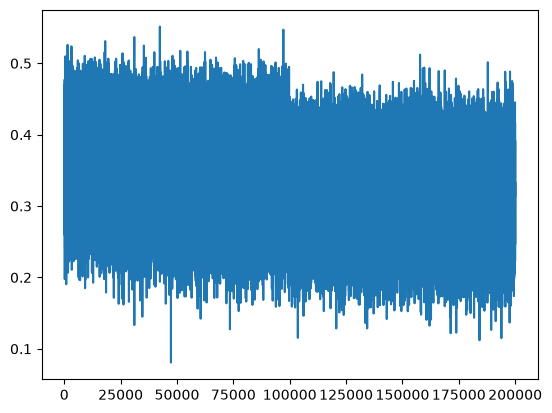

In [11]:
plt.plot(lossi)

## Evaluate

In [12]:
@torch.no_grad() # disable gradient tracking for the function
def split_loss(split): 
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y) 
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.091226577758789
val 2.1396918296813965


## Sample from the model

In [13]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True: 
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmah.
amille.
khi.
mritheaty.
skansh.
emmahnel.
deliah.
jarqui.
nellara.
chaiir.
kaleigh.
ham.
poin.
quinn.
sulin.
alianni.
waleah.
dearyxik.
kaellinsley.
dai.
